# NBA Betting Prediction Model — XGBoost Training Pipeline

**Target:** Predict `home_win` (1 = home team wins)  
**Goal:** ≥ 70% accuracy OR positive ROI betting strategy  
**Data:** 30,474 games | 22 seasons (2003–2025) | 56 engineered features

---
### Notebook Structure
1. Setup & Data Loading
2. Exploratory Analysis
3. Time-Series Train/Test Split
4. Feature Engineering & Selection
5. Baseline XGBoost Model
6. Hyperparameter Tuning
7. Final Model Training
8. Evaluation (Accuracy, AUC, LogLoss, Calibration)
9. Betting Simulation (ROI, EV, Win Rate)
10. Probability Calibration
11. Feature Importance
12. Save Model for Production

## 1. Setup & Data Loading

In [1]:
import sys, os, warnings, joblib
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    confusion_matrix, classification_report,
    brier_score_loss, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

print('XGBoost version:', xgb.__version__)
print('Pandas version: ', pd.__version__)

Matplotlib is building the font cache; this may take a moment.


XGBoost version: 3.2.0
Pandas version:  3.0.2


In [2]:
# ── Load master dataset ──────────────────────────────────────────────────────
MASTER_PATH  = '../data/master_dataset.csv'
MODELS_DIR   = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

master = pd.read_csv(MASTER_PATH, parse_dates=['game_date'])
master = master.sort_values('game_date').reset_index(drop=True)

print(f'Loaded: {master.shape[0]:,} rows x {master.shape[1]} columns')
print(f'Date range: {master.game_date.min().date()} to {master.game_date.max().date()}')
print(f'Seasons: {sorted(master.season.unique())}')
master.head(3)

Loaded: 30,474 rows x 63 columns
Date range: 2003-10-31 to 2025-02-12
Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,game_id,game_date,season,home_team_id,away_team_id,home_win,elo_home,elo_away,elo_difference,elo_rolling_five_home,elo_rolling_five_away,implied_prob_home,pace_home,pace_away,pace_difference,field_goal_difference,shooting_pct_home,shooting_pct_away,ppg_10_home,opp_ppg_10_home,fg_pct_roll_10_home,ft_pct_roll_10_home,fg3_pct_roll_10_home,last_5_win_rate_home,last_10_win_rate_home,offensive_rating_home,defensive_rating_home,net_rating_home,turnovers_per_game_home,opponent_off_rating_10_home,opponent_def_rating_10_home,player_impact_estimate_home,player_injury_flag_home,injured_count_home,star_available_home,star_count_home,rest_days_home,back_to_back_home,fatigue_load_index_home,coaching_adaptability_score_home,ppg_10_away,opp_ppg_10_away,fg_pct_roll_10_away,ft_pct_roll_10_away,fg3_pct_roll_10_away,last_5_win_rate_away,last_10_win_rate_away,offensive_rating_away,defensive_rating_away,net_rating_away,turnovers_per_game_away,opponent_off_rating_10_away,opponent_def_rating_10_away,player_impact_estimate_away,player_injury_flag_away,injured_count_away,star_available_away,star_count_away,rest_days_away,back_to_back_away,fatigue_load_index_away,coaching_adaptability_score_away,line_movement
0,20300020,2003-10-31,2003,1610612748,1610612765,0,1492.0736,1487.7176,4.3560,1502.2709,1495.8449,0.6458,86.4400,85.4000,1.0400,-0.0780,0.4313,0.5008,78.3333,88.6667,0.3753,0.7403,0.2963,0.3333,0.3333,86.3971,97.7941,-11.3971,16.6667,96.9726,93.9316,0.4300,1,2,1,0,2,0,2,0.0909,95.6667,92.6667,0.4253,0.6807,0.3543,0.3333,0.3333,96.9726,93.9316,3.0410,16.6667,86.3971,97.7941,0.5316,0,0,1,0,2,0,1,0.0909,NaN
1,20300027,2003-11-01,2003,1610612764,1610612751,0,1505.2849,1512.6983,-7.4135,1504.8573,1506.0866,0.6302,92.8000,92.8000,0.0000,-0.0050,0.4705,0.5107,88.2500,79.5000,0.4485,0.6933,0.3500,0.5000,0.5000,96.9887,87.3722,9.6164,18.0000,97.3236,82.2957,0.5821,1,1,1,0,1,1,2,0.0909,90.6667,76.6667,0.4423,0.6810,0.2490,0.6667,0.6667,97.3236,82.2957,15.0279,13.6667,96.9887,87.3722,0.6634,1,2,1,0,1,1,2,0.0909,NaN
2,20300029,2003-11-01,2003,1610612737,1610612754,0,1473.6343,1506.1400,-32.5057,1489.4641,1509.0052,0.5959,102.6400,102.2800,0.3600,0.0200,0.5057,0.4696,85.6667,90.3333,0.3827,0.7337,0.4087,0.0000,0.0000,84.2844,88.8758,-4.5914,18.0000,91.8530,95.0479,0.4424,1,3,1,1,1,1,2,0.0909,76.6667,79.3333,0.4097,0.6643,0.3500,0.6667,0.6667,91.8530,95.0479,-3.1949,12.6667,84.2844,88.8758,0.4435,1,3,1,1,1,1,2,0.0909,NaN


## 2. Exploratory Analysis

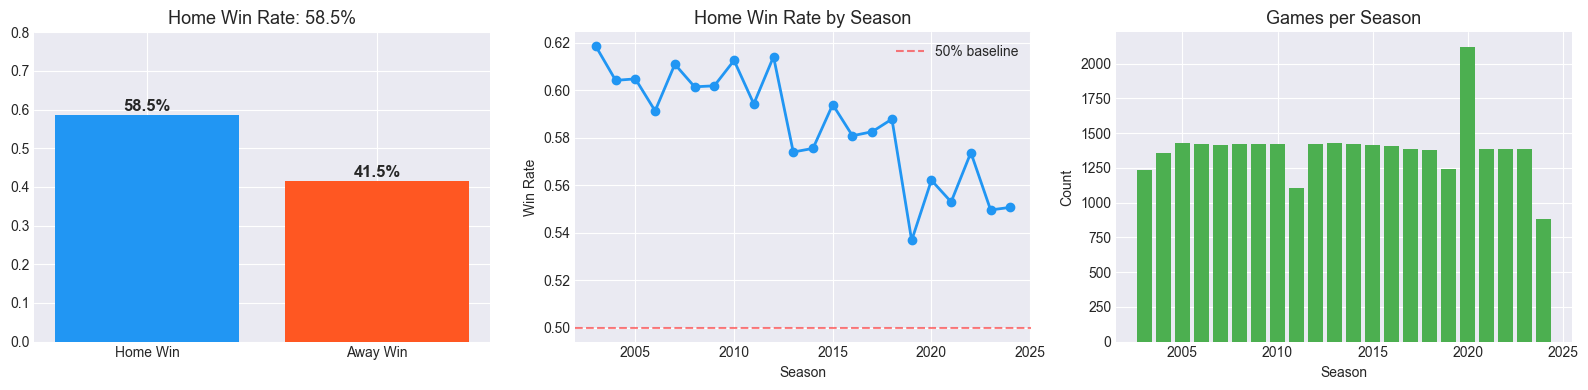

Class balance — Home Win: 58.5% | Away Win: 41.5%
NOTE: 58.5% home win rate = realistic NBA baseline. Model must beat this.


In [3]:
# ── Target distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Overall win rate
win_rate = master['home_win'].mean()
axes[0].bar(['Home Win', 'Away Win'], [win_rate, 1-win_rate], color=['#2196F3','#FF5722'])
axes[0].set_title(f'Home Win Rate: {win_rate:.1%}', fontsize=13)
axes[0].set_ylim(0, 0.8)
for i, v in enumerate([win_rate, 1-win_rate]):
    axes[0].text(i, v+0.01, f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')

# Win rate by season
season_wr = master.groupby('season')['home_win'].mean()
axes[1].plot(season_wr.index, season_wr.values, marker='o', linewidth=2, color='#2196F3')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1].set_title('Home Win Rate by Season', fontsize=13)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Win Rate')
axes[1].legend()

# Games per season
games_per_season = master.groupby('season').size()
axes[2].bar(games_per_season.index, games_per_season.values, color='#4CAF50')
axes[2].set_title('Games per Season', fontsize=13)
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(f'Class balance — Home Win: {win_rate:.1%} | Away Win: {1-win_rate:.1%}')
print('NOTE: 58.5% home win rate = realistic NBA baseline. Model must beat this.')

In [ ]:
# ── Feature correlation with target ──────────────────────────────────────────
DROP_COLS = ['game_id', 'game_date', 'season', 'home_team_id', 'away_team_id',
             'home_win', 'line_movement']
FEATURE_COLS = [c for c in master.columns if c not in DROP_COLS]

corr_with_target = (
    master[FEATURE_COLS + ['home_win']]
    .corr()['home_win']
    .drop('home_win')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2196F3' if x > 0 else '#FF5722' for x in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with home_win (target)', fontsize=14)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Top 10 most correlated features:')
print(corr_with_target.head(10).to_string())

## 3. Time-Series Train / Validation / Test Split

> **Critical rule**: NEVER shuffle sports data. Always split by time.  
> Using a future season to evaluate ensures we test on truly unseen data.

In [ ]:
# ── Split strategy ────────────────────────────────────────────────────────────
# Train  : 2003 – 2021  (18 seasons, ~24k games)
# Valid  : 2022 – 2023  (2 seasons, ~3k games)  ← for hyperparameter tuning
# Test   : 2024         (1 season,  ~1.4k games) ← final evaluation ONLY

TRAIN_END   = 2021
VALID_START = 2022
VALID_END   = 2023
TEST_START  = 2024

train_df = master[master['season'] <= TRAIN_END].copy()
valid_df = master[(master['season'] >= VALID_START) & (master['season'] <= VALID_END)].copy()
test_df  = master[master['season'] >= TEST_START].copy()

print(f'Train : {len(train_df):>6,} rows | seasons {master[master.season<=TRAIN_END].season.min()}–{TRAIN_END}')
print(f'Valid : {len(valid_df):>6,} rows | seasons {VALID_START}–{VALID_END}')
print(f'Test  : {len(test_df):>6,} rows | season  {TEST_START}+')

X_train = train_df[FEATURE_COLS]
y_train = train_df['home_win']

X_valid = valid_df[FEATURE_COLS]
y_valid = valid_df['home_win']

X_test  = test_df[FEATURE_COLS]
y_test  = test_df['home_win']

print(f'\nTrain home win rate: {y_train.mean():.3f}')
print(f'Valid home win rate: {y_valid.mean():.3f}')
print(f'Test  home win rate: {y_test.mean():.3f}')

## 4. Feature Engineering & Selection

In [ ]:
# ── Add differential features (home minus away) ───────────────────────────────
# These are stronger than raw home/away values because they directly capture
# the matchup gap. XGBoost can learn this implicitly but giving it explicitly
# helps convergence and reduces tree depth needed.

def add_differential_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    diff_pairs = [
        ('elo_home',                    'elo_away'),
        ('net_rating_home',             'net_rating_away'),
        ('offensive_rating_home',       'offensive_rating_away'),
        ('defensive_rating_home',       'defensive_rating_away'),
        ('last_5_win_rate_home',        'last_5_win_rate_away'),
        ('last_10_win_rate_home',       'last_10_win_rate_away'),
        ('ppg_10_home',                 'ppg_10_away'),
        ('rest_days_home',              'rest_days_away'),
        ('fatigue_load_index_home',     'fatigue_load_index_away'),
        ('turnovers_per_game_home',     'turnovers_per_game_away'),
        ('player_impact_estimate_home', 'player_impact_estimate_away'),
        ('injured_count_home',          'injured_count_away'),
        ('coaching_adaptability_score_home', 'coaching_adaptability_score_away'),
    ]
    for col_a, col_b in diff_pairs:
        if col_a in df.columns and col_b in df.columns:
            name = col_a.replace('_home', '') + '_diff'
            df[name] = df[col_a] - df[col_b]
    return df

# Apply to all splits
master    = add_differential_features(master)
train_df  = add_differential_features(train_df)
valid_df  = add_differential_features(valid_df)
test_df   = add_differential_features(test_df)

# ── Update feature list ───────────────────────────────────────────────────────
DIFF_FEATURES = [c for c in master.columns if c.endswith('_diff')]
ALL_FEATURES  = FEATURE_COLS + DIFF_FEATURES

# Remove features with near-zero variance (noise)
var_threshold = 1e-4
low_var = [c for c in ALL_FEATURES
           if c in train_df.columns and train_df[c].var() < var_threshold]
ALL_FEATURES = [c for c in ALL_FEATURES if c not in low_var]

print(f'Base features   : {len(FEATURE_COLS)}')
print(f'Differential    : {len(DIFF_FEATURES)}')
print(f'Dropped low-var : {len(low_var)} -> {low_var}')
print(f'Final features  : {len(ALL_FEATURES)}')
print(f'Diff features   : {DIFF_FEATURES}')

In [ ]:
# ── Build final X/y ───────────────────────────────────────────────────────────
X_train = train_df[ALL_FEATURES].fillna(0)
y_train = train_df['home_win']

X_valid = valid_df[ALL_FEATURES].fillna(0)
y_valid = valid_df['home_win']

X_test  = test_df[ALL_FEATURES].fillna(0)
y_test  = test_df['home_win']

print(f'X_train : {X_train.shape}')
print(f'X_valid : {X_valid.shape}')
print(f'X_test  : {X_test.shape}')
print('Missing values in train:', X_train.isnull().sum().sum())

## 5. Baseline Model

In [ ]:
# ── Baseline XGBoost (default params) ────────────────────────────────────────
baseline = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)

baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50,
)

# Evaluate on validation
val_preds  = baseline.predict(X_valid)
val_probs  = baseline.predict_proba(X_valid)[:, 1]

print(f'\nBaseline Validation Results:')
print(f'  Accuracy : {accuracy_score(y_valid, val_preds):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_valid, val_probs):.4f}')
print(f'  Log Loss : {log_loss(y_valid, val_probs):.4f}')
print(f'  Brier    : {brier_score_loss(y_valid, val_probs):.4f}')

## 6. Hyperparameter Tuning (Randomized Search)

In [ ]:
# ── Hyperparameter search ─────────────────────────────────────────────────────
# Strategy: RandomizedSearch over wide ranges first, then narrow down.
# We use TimeSeriesSplit on the TRAINING SET ONLY to avoid leakage.

param_grid = {
    'n_estimators'      : [200, 400, 600, 800, 1000],
    'max_depth'         : [3, 4, 5, 6],
    'learning_rate'     : [0.01, 0.02, 0.05, 0.08, 0.1],
    'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree'  : [0.5, 0.6, 0.7, 0.8, 0.9],
    'min_child_weight'  : [1, 3, 5, 7],
    'gamma'             : [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha'         : [0, 0.01, 0.1, 0.5, 1.0],   # L1 regularization
    'reg_lambda'        : [0.5, 1.0, 1.5, 2.0, 3.0],  # L2 regularization
}

# TimeSeriesSplit — ensures each fold uses earlier data for training
tscv = TimeSeriesSplit(n_splits=5)

xgb_search = xgb.XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

random_search = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=param_grid,
    n_iter=50,             # 50 random combinations
    scoring='roc_auc',     # optimize AUC, not just accuracy
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print('Best params:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best CV AUC: {random_search.best_score_:.4f}')

## 7. Final Model Training

In [ ]:
# ── Train final model with best params + early stopping ──────────────────────
best_params = random_search.best_params_.copy()

# Override n_estimators with a high ceiling and let early stopping find optimum
best_params['n_estimators'] = 2000

final_model = xgb.XGBClassifier(
    **best_params,
    eval_metric='logloss',
    early_stopping_rounds=40,
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=100,
)

print(f'Best iteration: {final_model.best_iteration}')

# Learning curves
results = final_model.evals_result()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results['validation_0']['logloss'], label='Train', alpha=0.8)
ax.plot(results['validation_1']['logloss'], label='Validation', alpha=0.8)
ax.axvline(final_model.best_iteration, color='red', linestyle='--',
           label=f'Best iteration ({final_model.best_iteration})')
ax.set_xlabel('Boosting Rounds')
ax.set_ylabel('Log Loss')
ax.set_title('Learning Curves — Train vs Validation')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Evaluation Framework

In [ ]:
# ── Full evaluation on TEST SET (season 2024 — never seen during training) ───
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

acc    = accuracy_score(y_test, test_preds)
auc    = roc_auc_score(y_test, test_probs)
ll     = log_loss(y_test, test_probs)
brier  = brier_score_loss(y_test, test_probs)

print('=' * 50)
print('  FINAL TEST SET EVALUATION (Season 2024)')
print('=' * 50)
print(f'  Accuracy     : {acc:.4f}  ({acc:.1%})')
print(f'  ROC-AUC      : {auc:.4f}')
print(f'  Log Loss     : {ll:.4f}  (lower = better)')
print(f'  Brier Score  : {brier:.4f} (lower = better)')
print(f'  Baseline acc : {y_test.mean():.4f} (always predict home win)')
print(f'  Improvement  : +{acc - y_test.mean():.4f} over baseline')
print('=' * 50)
print()
print(classification_report(y_test, test_preds, target_names=['Away Win', 'Home Win']))

In [ ]:
# ── Confusion matrix + ROC curve ─────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Away Win', 'Home Win'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Test Set', fontsize=13)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, color='#2196F3', linewidth=2,
             label=f'XGBoost (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Betting Simulation — ROI, Win Rate, Expected Value

> **Core idea**: Don't bet every game. Only bet when the model's predicted  
> probability meaningfully exceeds the market implied probability (edge > 0).
>
> `Edge = model_prob - market_implied_prob`  
> `EV   = edge × stake`  
> `ROI  = total_profit / total_staked`

In [ ]:
# ── Betting simulation engine ─────────────────────────────────────────────────

def simulate_betting(
    y_true: pd.Series,
    model_probs: np.ndarray,
    market_odds: np.ndarray = None,
    threshold: float = 0.55,
    edge_min: float = 0.03,
    stake: float = 100.0,
    label: str = '',
) -> pd.DataFrame:
    """
    Simulate flat-stake betting on games where model has edge.

    Parameters
    ----------
    y_true       : actual outcomes
    model_probs  : model's P(home_win)
    market_odds  : market implied P(home_win). If None, uses implied_prob_home from dataset.
    threshold    : minimum model probability to bet home
    edge_min     : minimum edge over market to place bet (anti-vig filter)
    stake        : flat bet size per game
    """
    df = pd.DataFrame({
        'actual'    : y_true.values,
        'model_prob': model_probs,
        'market_p'  : market_odds if market_odds is not None else 0.585,
    })

    # Decide bet direction
    df['bet_home'] = (
        (df['model_prob'] >= threshold) &
        (df['model_prob'] - df['market_p'] >= edge_min)
    ).astype(int)
    df['bet_away'] = (
        (df['model_prob'] <= (1 - threshold)) &
        (df['market_p'] - df['model_prob'] >= edge_min)
    ).astype(int)

    df['bet_placed'] = df['bet_home'] | df['bet_away']

    # Standard -110 odds (bet $110 to win $100) = payout factor 0.909
    PAYOUT = 0.909

    df['profit'] = np.where(
        df['bet_home'] == 1,
        np.where(df['actual'] == 1,  stake * PAYOUT, -stake),
        np.where(
            df['bet_away'] == 1,
            np.where(df['actual'] == 0, stake * PAYOUT, -stake),
            0.0
        )
    )

    bets       = df[df['bet_placed'] == 1]
    total_bet  = len(bets) * stake
    total_prof = bets['profit'].sum()
    win_rate   = (bets['profit'] > 0).mean() if len(bets) > 0 else 0
    roi        = total_prof / total_bet if total_bet > 0 else 0

    print(f'\n--- Betting Simulation {label} ---')
    print(f'  Games available : {len(df):,}')
    print(f'  Bets placed     : {len(bets):,} ({len(bets)/len(df):.1%} of games)')
    print(f'  Win rate        : {win_rate:.1%}')
    print(f'  Total staked    : ${total_bet:,.0f}')
    print(f'  Total profit    : ${total_prof:,.0f}')
    print(f'  ROI             : {roi:.2%}')
    print(f'  EV per bet      : ${total_prof/max(len(bets),1):.2f}')

    return df

# Use ELO-implied prob as market proxy (replace with real odds data when available)
market_probs_test = test_df['implied_prob_home'].values

# Run simulations at different confidence thresholds
for thresh in [0.52, 0.55, 0.58, 0.60, 0.63]:
    simulate_betting(
        y_test, test_probs,
        market_odds=market_probs_test,
        threshold=thresh,
        edge_min=0.02,
        label=f'threshold={thresh}'
    )

In [ ]:
# ── ROI by probability bucket ─────────────────────────────────────────────────
# Shows which confidence range actually makes money

test_results = pd.DataFrame({
    'actual'     : y_test.values,
    'model_prob' : test_probs,
    'prob_bucket': pd.cut(test_probs, bins=10, labels=False),
})

bucket_stats = test_results.groupby('prob_bucket').agg(
    games=('actual', 'count'),
    actual_win_rate=('actual', 'mean'),
    avg_model_prob=('model_prob', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
x = bucket_stats['avg_model_prob']
ax.bar(x, bucket_stats['actual_win_rate'], width=0.07, alpha=0.7,
       label='Actual Win Rate', color='#2196F3')
ax.plot(x, x, 'r--', label='Perfect Calibration', linewidth=2)
ax.set_xlabel('Model Predicted Probability')
ax.set_ylabel('Actual Win Rate')
ax.set_title('Calibration: Predicted vs Actual Win Rate by Bucket', fontsize=13)
ax.legend()

# Annotate with game counts
for _, row in bucket_stats.iterrows():
    ax.annotate(f"n={int(row['games'])}", (row['avg_model_prob'], row['actual_win_rate'] + 0.01),
                ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 10. Probability Calibration

> XGBoost probabilities are often overconfident.  
> Calibration corrects this so `P=0.65` really means the team wins 65% of the time.  
> This is **critical for betting** — miscalibrated probs lead to wrong EV calculations.

In [ ]:
# ── Isotonic Regression calibration ──────────────────────────────────────────
# Isotonic > Platt (sigmoid) for XGBoost because XGB already uses sigmoid
# internally. Isotonic is non-parametric and handles non-linear miscalibration.

calibrated_model = CalibratedClassifierCV(
    final_model,
    method='isotonic',   # 'sigmoid' = Platt scaling (faster, less data needed)
    cv='prefit',         # model is already trained; fit calibrator only
)
calibrated_model.fit(X_valid, y_valid)  # fit calibrator on VALIDATION set

# Compare raw vs calibrated probabilities
cal_probs = calibrated_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, title in [
    (axes[0], test_probs, 'Raw XGBoost Probabilities'),
    (axes[1], cal_probs,  'After Isotonic Calibration'),
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', label='Model', color='#2196F3', linewidth=2)
    ax.plot([0,1], [0,1], 'k--', label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(title, fontsize=13)
    ax.legend()

plt.suptitle('Reliability Diagram', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Brier scores
print(f'Brier Score (raw)        : {brier_score_loss(y_test, test_probs):.4f}')
print(f'Brier Score (calibrated) : {brier_score_loss(y_test, cal_probs):.4f}')
print(f'Calibrated accuracy      : {accuracy_score(y_test, (cal_probs>=0.5).astype(int)):.4f}')

## 11. Feature Importance

In [ ]:
# ── Three types of XGBoost feature importance ─────────────────────────────────
# weight   : how many times a feature is used to split
# gain     : average improvement in loss when feature is used (MOST RELIABLE)
# cover    : average coverage of samples affected by splits on this feature

importance_gain = pd.Series(
    final_model.get_booster().get_score(importance_type='gain'),
    name='gain'
).sort_values(ascending=False)

importance_weight = pd.Series(
    final_model.get_booster().get_score(importance_type='weight'),
    name='weight'
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top_n = 25
for ax, imp, title in [
    (axes[0], importance_gain.head(top_n),   f'Top {top_n} Features by Gain'),
    (axes[1], importance_weight.head(top_n), f'Top {top_n} Features by Weight'),
]:
    ax.barh(imp.index[::-1], imp.values[::-1], color='#2196F3')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Importance Score')

plt.suptitle('XGBoost Feature Importance', fontsize=15)
plt.tight_layout()
plt.show()

print('Top 15 features by GAIN (most predictive):')
print(importance_gain.head(15).to_string())

In [ ]:
# ── SHAP values (detailed feature impact per prediction) ─────────────────────
# SHAP explains WHY the model made each prediction — essential for trust & debugging

try:
    import shap
    explainer  = shap.TreeExplainer(final_model)
    shap_vals  = explainer.shap_values(X_test)

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_test, plot_type='bar', show=False,
                      max_display=20)
    plt.title('SHAP Feature Importance — Mean |SHAP value|', fontsize=14)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_vals, X_test, show=False, max_display=20)
    plt.title('SHAP Beeswarm — Feature Impact Direction', fontsize=14)
    plt.tight_layout()
    plt.show()

except ImportError:
    print('SHAP not installed. Run: pip install shap')
    print('Skipping SHAP analysis.')

## 12. Save Models for Production

In [ ]:
# ── Save all artifacts ────────────────────────────────────────────────────────
import json
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M')

# 1. Raw XGBoost model (JSON — portable, version-safe)
model_path = f'{MODELS_DIR}/xgb_nba_{timestamp}.json'
final_model.save_model(model_path)
print(f'Saved XGBoost model     : {model_path}')

# 2. Calibrated model (joblib)
cal_path = f'{MODELS_DIR}/xgb_nba_calibrated_{timestamp}.joblib'
joblib.dump(calibrated_model, cal_path)
print(f'Saved calibrated model  : {cal_path}')

# 3. Feature list (critical — must match training)
feat_path = f'{MODELS_DIR}/feature_list_{timestamp}.json'
with open(feat_path, 'w') as f:
    json.dump(ALL_FEATURES, f, indent=2)
print(f'Saved feature list      : {feat_path}')

# 4. Model metadata
meta = {
    'timestamp'       : timestamp,
    'train_seasons'   : f'2003-{TRAIN_END}',
    'valid_seasons'   : f'{VALID_START}-{VALID_END}',
    'test_season'     : str(TEST_START),
    'n_features'      : len(ALL_FEATURES),
    'n_train_rows'    : len(X_train),
    'test_accuracy'   : round(acc, 4),
    'test_auc'        : round(auc, 4),
    'test_logloss'    : round(ll, 4),
    'best_iteration'  : final_model.best_iteration,
    'best_params'     : best_params,
}
meta_path = f'{MODELS_DIR}/model_meta_{timestamp}.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Saved model metadata    : {meta_path}')

print(f'\nAll artifacts saved to: {MODELS_DIR}/')

## Summary Card

In [ ]:
# ── Final summary ─────────────────────────────────────────────────────────────
cal_acc = accuracy_score(y_test, (cal_probs >= 0.5).astype(int))
cal_auc = roc_auc_score(y_test, cal_probs)

print('=' * 55)
print('  NBA BETTING MODEL — FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  Dataset          : {len(master):,} games (2003-2025)')
print(f'  Features used    : {len(ALL_FEATURES)}')
print(f'  Test season      : 2024')
print()
print('  --- Classification Metrics ---')
print(f'  Raw  Accuracy  : {acc:.4f}  ({acc:.1%})')
print(f'  Cal  Accuracy  : {cal_acc:.4f}  ({cal_acc:.1%})')
print(f'  ROC-AUC        : {auc:.4f}')
print(f'  Log Loss       : {ll:.4f}')
print(f'  Brier Score    : {brier:.4f}')
print(f'  Baseline (%)   : {y_test.mean():.4f}')
print()
print('  --- Model Info ---')
print(f'  Best iteration : {final_model.best_iteration}')
print(f'  Best CV AUC    : {random_search.best_score_:.4f}')
print()
print('  --- Next Steps ---')
print('  1. Add real betting odds to line_movement column')
print('  2. Integrate real-time injury reports before game time')
print('  3. Set up daily retraining cron job')
print('  4. Backtest full Kelly criterion bet sizing')
print('=' * 55)